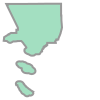

In [3]:
import shapely
from MobilityHubDataObjects import *
import pandas as pd
import geopandas as gpd
import folium
import numpy as np
from pyproj import Transformer
import datetime as dt

#map_area = gpd.read_file("./rawData/LA_City_Boundary/City_Boundary.shp").to_crs("EPSG:4326").loc[0, "geometry"]
#map_area = gpd.read_file("./rawData/LA_Times_Neighborhood_Boundaries.geojson").loc[65, "geometry"]
map_area = gpd.read_file("./rawData/losangelescounty.geojson").to_crs(4326).loc[0,"geometry"]
map_area

In [ ]:
gtfs_instance = GTFSDataObject(
    "./gtfs/losangeles",
    "https://transit.land/api/v2/rest/feeds.json",
    dt.timedelta(days=10),
    dt.time(hour=10), #TODO: need to handle tz
    dt.time(hour=15),
    min_headway=9000,
    api_key_path="./rawData/TRANSITLAND_KEY",
)
await gtfs_instance.load_data(map_area, load_area_crs=4269)

INFO: Transitland URL: https://transit.land/api/v2/rest/feeds.json?bbox=-118.951721,32.75004,-117.646374,34.823302&limit=100&license_create_derived_product=exclude_no&license_redistribution_allowed=exclude_no&apikey=iMGHYCuvlmhChyTvB9gmQuDonmXnj91W
INFO: Transitland URL: https://transit.land/api/v2/rest/feeds.json?bbox=-118.2990475,33.786671,-117.646374,34.823302&limit=100&license_create_derived_product=exclude_no&license_redistribution_allowed=exclude_no&apikey=iMGHYCuvlmhChyTvB9gmQuDonmXnj91W
INFO: Transitland URL: https://transit.land/api/v2/rest/feeds.json?bbox=-118.951721,33.786671,-118.2990475,34.823302&limit=100&license_create_derived_product=exclude_no&license_redistribution_allowed=exclude_no&apikey=iMGHYCuvlmhChyTvB9gmQuDonmXnj91W
INFO: Transitland URL: https://transit.land/api/v2/rest/feeds.json?bbox=-118.951721,32.75004,-118.2990475,33.786671&limit=100&license_create_derived_product=exclude_no&license_redistribution_allowed=exclude_no&apikey=iMGHYCuvlmhChyTvB9gmQuDonmXnj91W

In [ ]:
gtfs_instance._recursively_make_transitland_call_help(100, map_area.bounds, 16)

In [ ]:
citybikes_instance = CityBikesDataObject("http://api.citybik.es/")
citybikes_instance.load_data(map_area, load_area_crs=4269)

In [5]:
fta_instance = FTAFacilityInventoryDataObject(
    "./rawData/2022 Facility Inventory.xlsx",
    column_filter={
        "Facility Type": [
            "Underground Fixed Guideway Station",
            "At-Grade Fixed Guideway Station",
            "Elevated Fixed Guideway Station",
        ]
    }
)
fta_instance.load_data(map_area)

In [ ]:
afdc_instance = AFDCApiDataObject(constants.AFDC_DATA_URL, "./cache/afdc_cache.geojson", "./rawData/AFDC_API_KEY")
afdc_instance.load_data(map_area)

In [7]:
osm_instance = OSMDataObject("./cache/osmnx_cache", {"amenity": ["bicycle_parking"]})
osm_instance.load_data(map_area)

In [8]:
ejscreen_instance = EJScreenDataObject("rawData/EJScreen_2024_BG_with_AS_CNMI_GU_VI.gdb")
ejscreen_instance.load_data(map_area, load_area_crs=4269)

In [ ]:
display_map = folium.Map(
    location=(map_area.centroid.y, map_area.centroid.x),
    tiles="Cartodb Positron",
    zoom_start=10,
)
ejscreen_instance.get_folium_plot().add_to(display_map)
afdc_instance.get_folium_plot().add_to(display_map)
fta_instance.get_folium_plot().add_to(display_map)
osm_instance.get_folium_plot().add_to(display_map)
#ipcd_instance.get_folium_plot().add_to(display_map)
gtfs_instance.get_folium_plot().add_to(display_map)
citybikes_instance.get_folium_plot().add_to(display_map)
display_map